100%|██████████| 100000/100000 [00:26<00:00, 3822.44it/s]


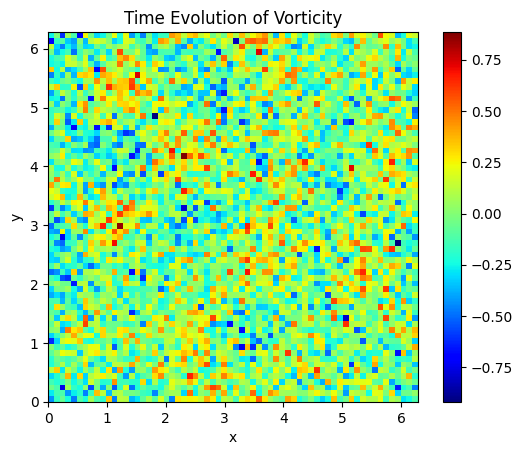

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from numpy.fft import fft2, ifft2, fftshift, fftfreq
from fluidfft import import_fft_class
import fluidfft
from tqdm import tqdm

# -------------------------------
# Grid and Simulation Parameters
# -------------------------------
L = 2 * np.pi
N = 64
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
nu = 0.002
X, Y = np.meshgrid(x, y)

# Choose the FFT method
method = 'fft2d.with_pyfftw'
FFT2D = import_fft_class(method)

# Create an instance of the FFT class
fft2d = FFT2D(int(N), int(N))

# Get kx and ky from fluidfft (for computing the wave vectors)
kx = fft2d.get_k_adim_loc()[1] * 2 * np.pi / L
ky = fft2d.get_k_adim_loc()[0] * 2 * np.pi / L
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
# print(np.where(K2 == 0))

# Dealiasing and forcing parameters
N_cutoff = int(2/3 * N)
dealias_mask = (K2 < (N_cutoff**2))

kinf = 1    # Lower bound for forcing wavenumbers
ksup = 4    # Upper bound for forcing wavenumbers
alpha = 0.05  # Damping coefficient

# ---------------------------------------
# Helper functions for forward/backward
# ---------------------------------------
def fluidfft_fft2d(variable):
    return fft2d.fft2d(variable)

def fluidfft_ifft2d(variable):
    return fft2d.ifft2d(variable)

# -------------------------------------
# Random Fourier Initial Condition
# -------------------------------------
def initial_condition_real_space(N):
    omega = np.random.randn(N, N)
    omega /= np.max(np.abs(omega))  # Normalize
    return omega

def initial_condition_restart(N, filename):
    omega = np.load(filename)
    return omega

# -------------------------------------
# Velocity, forcing, time stepping
# -------------------------------------
def psi_hat_fn(omega_hat):
    K2_temp = K2.copy()
    K2_temp[0, 0] = 1  # Avoid divide by zero
    psi_hat = omega_hat / K2_temp
    psi_hat[0, 0] = 0
    return psi_hat

def omega_hat_fn(psi_hat):
    K2_temp = K2.copy()
    K2_temp[0, 0] = 1  # Avoid divide by zero
    omega_hat = K2_temp * psi_hat
    omega_hat[0, 0] = 0
    return omega_hat

def velocity(omega_hat):
    psi_hat = psi_hat_fn(omega_hat)
    u = fluidfft_ifft2d(1j * KY * psi_hat).real
    v = fluidfft_ifft2d(-1j * KX * psi_hat).real
    return u, v

def calculate_nonlinear_term_hat(omega_hat, u, v):
    domega_dx_hat = 1j * KX * omega_hat
    domega_dy_hat = 1j * KY * omega_hat
    domega_dx = fluidfft_ifft2d(domega_dx_hat).real
    domega_dy = fluidfft_ifft2d(domega_dy_hat).real
    nonlinear_term = u * domega_dx + v * domega_dy
    nonlinear_term_hat = fluidfft_fft2d(nonlinear_term)
    return nonlinear_term_hat

def add_forcing(omega_hat, kinf, ksup, dt):
    psi_hat = psi_hat_fn(omega_hat)
    forcing_range = (np.sqrt(K2) >= (kinf)) & (np.sqrt(K2) <= (ksup))
    IIf = np.where(forcing_range)
    K2_valid = K2[IIf]
    K2_valid[K2_valid == 0] = 1e-30
    # print(K2_valid)
    factor = dt / (K2_valid * np.pi * (ksup - kinf) * (ksup + kinf))
    std_force = np.sqrt(factor)
    forcing = np.zeros_like(psi_hat, dtype=np.complex128)
    rand_complex = (np.random.randn(len(IIf[0])) + 1j*np.random.randn(len(IIf[0])))
    forcing[IIf] = std_force * rand_complex
    psi_hat += forcing
    omega_hat = omega_hat_fn(psi_hat)
    return omega_hat

def apply_damping(omega_hat, alpha, dt):
    # return omega_hat
    return omega_hat * np.exp(-alpha * dt * K2)

def time_stepping_with_snapshots(omega_hat, dt, T, snapshot_interval):
    """
    Time stepping that stores snapshots of the vorticity field
    for animation purposes.
    """
    snapshots = []
    steps = int(T / dt)
    snapshot_steps = int(snapshot_interval / dt)
    
    for step in tqdm(range(steps)):
        # Dealias
        omega_hat *= dealias_mask
        
        # Compute velocity
        u, v = velocity(omega_hat)
        
        # Compute nonlinear + advective terms
        nonlinear_term_hat = calculate_nonlinear_term_hat(omega_hat, u, v)
        
        # Add forcing and damping
        omega_hat = add_forcing(omega_hat, kinf, ksup, dt)
        omega_hat = apply_damping(omega_hat, alpha, dt)
        
        # Apply viscous term and finalize step
        omega_hat = omega_hat - dt * nonlinear_term_hat - dt * (nu * K2) * omega_hat
        
        # Save snapshot every snapshot_interval
        if step % snapshot_steps == 0:
            snapshots.append(fluidfft_ifft2d(omega_hat).real)
    
    return snapshots

# ----------------
# Main Script
# ----------------
if __name__ == '__main__':
    # 1) Create a random initial condition in real space
    omega = initial_condition_real_space(N)
    import scipy.io
    # mat_file = scipy.io.loadmat('vorticity_data.mat')
    # keys = [key for key in mat_file.keys() if not key.startswith('__')]
    # print("Variables in MAT file:", keys)
    # mat_variable = mat_file[keys[0]]
    # omega = np.array(mat_variable, dtype=np.complex128)
    
    
    # 2) Transform to spectral space
    omega_hat = fluidfft_fft2d(omega)
    
    # 3) Time-stepping with snapshots
    T = 50         # Total simulation time
    dt = 5e-4      # Time step size
    snapshot_interval = 0.1  # Save frame every 0.1 units of time
    snapshots = time_stepping_with_snapshots(omega_hat, dt, T, snapshot_interval)
    
    # ---------------------
    # Animation of Results
    # ---------------------
    fig, ax = plt.subplots()
    img = ax.imshow(snapshots[0], extent=(0, L, 0, L), origin='lower', cmap='jet')
    ax.set_title('Time Evolution of Vorticity')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    cbar = fig.colorbar(img, ax=ax)

    def update(frame):
        img.set_array(snapshots[frame])
        ax.set_title(f'Time Evolution of Vorticity (Frame {frame})')

        # Update colorbar limits dynamically
        img.set_clim(np.min(snapshots[frame]), np.max(snapshots[frame]))
        cbar.draw_all()  # Redraw colorbar
        
        return [img]

    # Use the 'ffmpeg' writer to save as an MP4 file
    # anim = FuncAnimation(fig, update, frames=len(snapshots), interval=50, blit=True)
    # anim.save('fluid_vorticity_evolution.mp4', writer='ffmpeg', fps=20)
    plt.show()


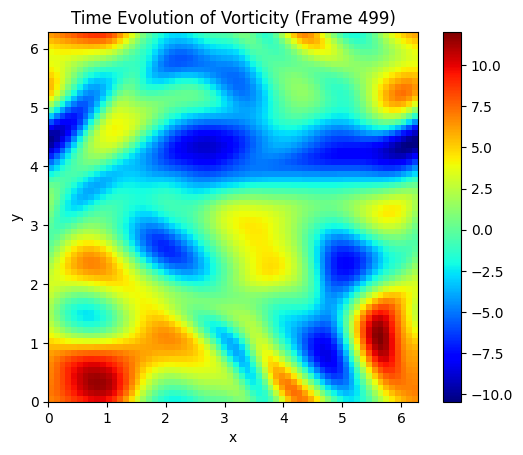

In [11]:
fig, ax = plt.subplots()
img = ax.imshow(snapshots[0], extent=(0, L, 0, L), origin='lower', cmap='jet')
ax.set_title('Time Evolution of Vorticity')
ax.set_xlabel('x')
ax.set_ylabel('y')
cbar = fig.colorbar(img, ax=ax)

def update(frame):
    img.set_array(snapshots[frame])
    ax.set_title(f'Time Evolution of Vorticity (Frame {frame})')

    # Update colorbar limits dynamically
    img.set_clim(np.min(snapshots[frame]), np.max(snapshots[frame]))
    fig.canvas.draw_idle() 
    
    return [img]

# Use the 'ffmpeg' writer to save as an MP4 file
anim = FuncAnimation(fig, update, frames=len(snapshots), interval=50, blit=True)
anim.save('fluid_vorticity_evolution.gif', writer='pillow')
plt.show()

In [14]:
anim.save('fluid_vorticity_evolution.gif', writer='pillow')

In [12]:
# Save snapshots[-1] as a numpy array .npy file
snapshots[-1] = np.array(snapshots[-1], dtype=np.complex128)
np.save('vorticity_final.npy', snapshots[-1])


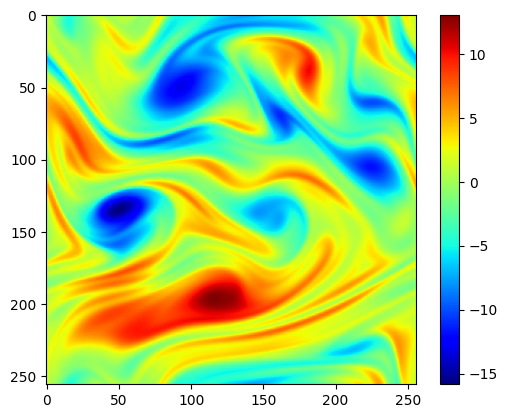

In [2]:
plt.imshow(snapshots[-1], cmap='jet')
plt.colorbar()
plt.savefig('fluid_vorticity_evolution.png')


In [13]:
def compute_energy_spectrum(omega_hat):
    """Computes energy spectrum E(k) and enstrophy spectrum Z(k)."""
    u, v = velocity(omega_hat)
    u_hat = fluidfft_fft2d(u)
    v_hat = fluidfft_fft2d(v)
    
    # Compute kinetic energy in Fourier space
    energy_hat = 0.5 * (np.abs(u_hat)**2 + np.abs(v_hat)**2)
    
    # Compute enstrophy spectrum
    enstrophy_hat = 0.5 * np.abs(omega_hat)**2

    # Compute wave numbers
    k_mag = np.sqrt(K2).flatten()
    energy_flat = energy_hat.flatten()
    enstrophy_flat = enstrophy_hat.flatten()

    # Bin energy and enstrophy into discrete wavenumbers
    k_bins = np.arange(1, int(np.max(k_mag)) + 1)
    E_k = np.zeros_like(k_bins, dtype=np.float64)
    Z_k = np.zeros_like(k_bins, dtype=np.float64)

    for i, k in enumerate(k_bins):
        mask = (k_mag >= k) & (k_mag < k + 20)
        if np.any(mask):
            E_k[i] = np.sum(energy_flat[mask])
            # Z_k[i] = np.sum(enstrophy_flat[mask])

    return k_bins, E_k, Z_k

def plot_power_loss_scaling(omega_hat):
    """Plots power loss scaling: E(k) and Z(k) in log-log scale."""
    k_vals, E_k, Z_k = compute_energy_spectrum(omega_hat)
    # print(k_vals, E_k)
    
    plt.figure(figsize=(10, 5))

    # Plot Energy Spectrum E(k)
    plt.subplot(1, 2, 1)
    plt.loglog(k_vals, E_k, 'o-', label=r'Energy Spectrum $E(k)$')
    # Plot a line with slope -5/3 (Kolmogorov scaling)
    k_ref = np.array([1, 100])
    # plt.loglog(k_ref, 10**(1) * k_ref**(-8/3), 'k--', label=r'$k^{-5/3}$ Kolmogorov Cascade')
    plt.loglog(k_ref, 10**(1.3) * k_ref**(-5.0), 'k--', label=r'$k^{-3}$ Cascade')

    # plt.loglog(k_ref, 10**(-3) * k_ref**(-3), 'r--', label=r'$k^{-3}$ Enstrophy Cascade')
    plt.xlabel(r'Wavenumber $k$', fontsize=14)
    plt.ylabel(r'Energy Spectrum $E(k)$', fontsize=14)
    plt.title('Energy Spectrum vs Wavenumber', fontsize=14)
    plt.legend()
    plt.grid(True)

    # # Plot Enstrophy Spectrum Z(k)
    # plt.subplot(1, 2, 2)
    # plt.loglog(k_vals, Z_k, 'o-', label=r'Enstrophy Spectrum $Z(k)$')
    # plt.loglog(k_ref, 10**(-3) * k_ref**(0), 'k--', label=r'$k^{0}$ (Enstrophy Const.)')
    # plt.loglog(k_ref, 10**(-3) * k_ref**(-1), 'r--', label=r'$k^{-1}$ Dissipation Range')
    # plt.xlabel(r'Wavenumber $k$', fontsize=14)
    # plt.ylabel(r'Enstrophy Spectrum $Z(k)$', fontsize=14)
    # plt.title('Enstrophy Spectrum vs Wavenumber', fontsize=14)
    # plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()

In [5]:
omega_snapshots = np.load('omega_snapshots.npy')

In [ ]:

omega = omega_snapshots[-1]
omega_hat = fluidfft_fft2d(omega)
u, v = velocity(omega_hat)
u_rms = np.sqrt(np.mean(u**2 + v**2))
k_f = (kinf + ksup) / 2
L_f = 2 * np.pi / k_f
Re = (u_rms * L_f) / nu
print(f"Reynolds number ≈ {Re:.2f}")


Reynolds number ≈ 3911.14


Variables in MAT file: ['Om']


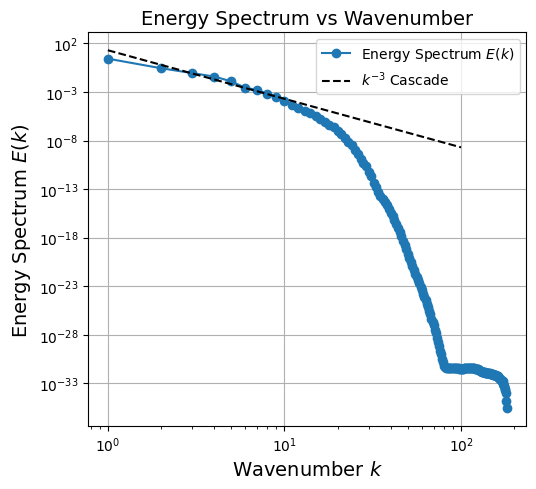

In [14]:
import numpy as np
import scipy.io
mat_file = scipy.io.loadmat('vorticity_data.mat')
keys = [key for key in mat_file.keys() if not key.startswith('__')]
print("Variables in MAT file:", keys)
mat_variable = mat_file[keys[0]]
# omega_test = np.array(mat_variable, dtype=np.complex128)
omega_test = snapshots[-1]


omega_test = omega_snapshots[-1]

omega_hat_test = fluidfft_fft2d(omega_test)
# omega_hat_test = omega_hat_fn(psi_hat_test)
plot_power_loss_scaling(omega_hat_test)

100%|██████████| 100000/100000 [03:22<00:00, 494.48it/s]
MovieWriter stderr:
[libopenh264 @ 0x5648a060a2c0] Incorrect library version loaded
Error initializing output stream 0:0 -- Error while opening encoder for output stream #0:0 - maybe incorrect parameters such as bit_rate, rate, width or height



CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '640x480', '-pix_fmt', 'rgba', '-framerate', '20', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'fluid_vorticity_evolution.mp4']' returned non-zero exit status 1.

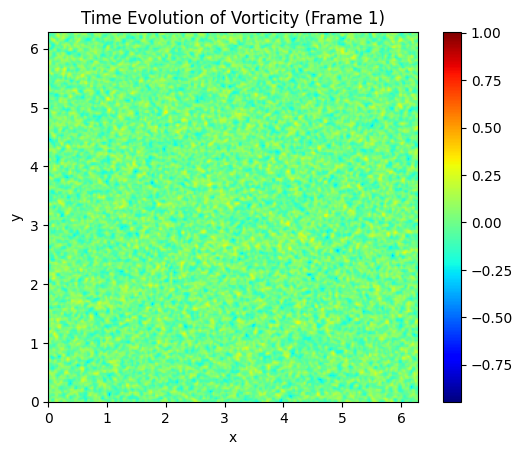

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from numpy.fft import fft2, ifft2, fftshift, fftfreq
from fluidfft import import_fft_class
import fluidfft
from tqdm import tqdm

# -------------------------------
# Grid and Simulation Parameters
# -------------------------------
L = 2 * np.pi
N = 256
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
nu = 0.002
X, Y = np.meshgrid(x, y)

# Choose the FFT method
method = 'fft2d.with_pyfftw'
FFT2D = import_fft_class(method)

# Create an instance of the FFT class
fft2d = FFT2D(int(N), int(N))

# Get kx and ky from fluidfft (for computing the wave vectors)
kx = fft2d.get_k_adim_loc()[1] * 2 * np.pi / L
ky = fft2d.get_k_adim_loc()[0] * 2 * np.pi / L
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2

# Dealiasing and forcing parameters
N_cutoff = int(2/3 * N)
dealias_mask = (K2 < (N_cutoff**2))

kinf = 1    # Lower bound for forcing wavenumbers
ksup = 4    # Upper bound for forcing wavenumbers
alpha = 0.05  # Damping coefficient

# ---------------------------------------
# Helper functions for forward/backward
# ---------------------------------------
def fluidfft_fft2d(variable):
    return fft2d.fft2d(variable)

def fluidfft_ifft2d(variable):
    return fft2d.ifft2d(variable)

# -------------------------------------
# Random Fourier Initial Condition
# -------------------------------------
def initial_condition_real_space(N):
    omega = np.random.randn(N, N)
    omega /= np.max(np.abs(omega))  # Normalize
    return omega

# -------------------------------------
# Velocity, forcing, time stepping
# -------------------------------------
def psi_hat_fn(omega_hat):
    K2_temp = K2.copy()
    K2_temp[0, 0] = 1  # Avoid divide by zero
    psi_hat = omega_hat / K2_temp
    psi_hat[0, 0] = 0
    return psi_hat

def velocity(omega_hat):
    psi_hat = psi_hat_fn(omega_hat)
    u = fluidfft_ifft2d(1j * KY * psi_hat).real
    v = fluidfft_ifft2d(-1j * KX * psi_hat).real
    return u, v

def calculate_nonlinear_term_hat(omega_hat, u, v):
    domega_dx_hat = 1j * KX * omega_hat
    domega_dy_hat = 1j * KY * omega_hat
    domega_dx = fluidfft_ifft2d(domega_dx_hat).real
    domega_dy = fluidfft_ifft2d(domega_dy_hat).real
    nonlinear_term = u * domega_dx + v * domega_dy
    nonlinear_term_hat = fluidfft_fft2d(nonlinear_term)
    return nonlinear_term_hat

def add_forcing(omega_hat, kinf, ksup, dt):
    # forcing_range = (K2 >= (kinf**2)) & (K2 <= (ksup**2))
    # forcing_amplitude = 1e-3
    # omega_hat[forcing_range] += forcing_amplitude * dt
    return omega_hat

def apply_damping(omega_hat, alpha, dt):
    # return omega_hat * np.exp(-alpha * dt * K2)
    return omega_hat

def time_stepping_with_snapshots(omega_hat, dt, T, snapshot_interval):
    """
    Time stepping that stores snapshots of the vorticity field
    for animation purposes.
    """
    snapshots1 = []
    steps = int(T / dt)
    snapshot_steps = int(snapshot_interval / dt)
    
    for step in tqdm(range(steps)):
        # Dealias
        omega_hat *= dealias_mask
        
        # Compute velocity
        u, v = velocity(omega_hat)
        
        # Compute nonlinear + advective terms
        nonlinear_term_hat = calculate_nonlinear_term_hat(omega_hat, u, v)
        
        # Add forcing and damping
        omega_hat = add_forcing(omega_hat, kinf, ksup, dt)
        omega_hat = apply_damping(omega_hat, alpha, dt)
        
        # Apply viscous term and finalize step
        omega_hat = omega_hat - dt * nonlinear_term_hat - dt * (nu * K2) * omega_hat
        
        # Save snapshot every snapshot_interval
        if step % snapshot_steps == 0:
            snapshots1.append(fluidfft_ifft2d(omega_hat).real)
    
    return snapshots1

# ----------------
# Main Script
# ----------------
if __name__ == '__main__':
    # 1) Create a random initial condition in real space
    omega = initial_condition_real_space(N)
    
    # 2) Transform to spectral space
    omega_hat = fluidfft_fft2d(omega)
    
    # 3) Time-stepping with snapshots
    T = 50         # Total simulation time
    dt = 5e-4      # Time step size
    snapshot_interval = 0.1  # Save frame every 0.1 units of time
    snapshots1 = time_stepping_with_snapshots(omega_hat, dt, T, snapshot_interval)
    
    # ---------------------
    # Animation of Results
    # ---------------------
    fig, ax = plt.subplots()
    img = ax.imshow(snapshots1[0], extent=(0, L, 0, L), origin='lower', cmap='jet')
    ax.set_title('Time Evolution of Vorticity')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(img, ax=ax)

    def update(frame):
        img.set_array(snapshots1[frame])
        ax.set_title(f'Time Evolution of Vorticity (Frame {frame})')
        return [img]

    # Use the 'ffmpeg' writer to save as an MP4 file
    anim = FuncAnimation(fig, update, frames=len(snapshots1), interval=50, blit=True)
    anim.save('fluid_vorticity_evolution.mp4', writer='ffmpeg', fps=20)
    plt.show()


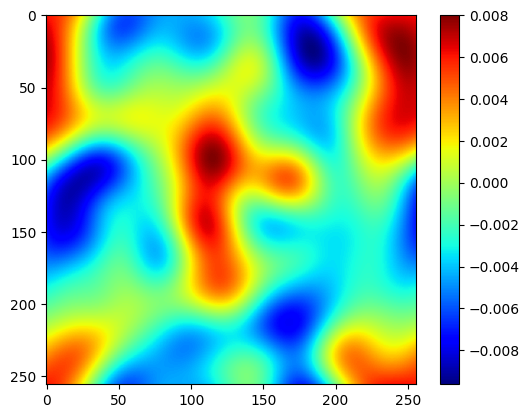

In [40]:
plt.imshow(snapshots1[-1], cmap='jet')
plt.colorbar()
plt.show()

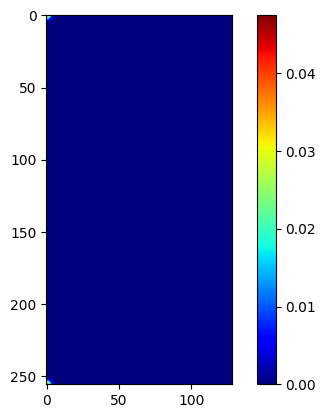

In [35]:
x_array = np.linspace(0, 256, 256)
y_array = np.linspace(0, 256, 256)
X, Y = np.meshgrid(x_array, y_array)
array = np.exp(-((X-128)**2 + (Y-128)**2)/1000)
fftarray = fft2d.fft2d(array)
# plt.imshow(array, cmap='jet')

plt.imshow(np.abs(fftarray), cmap='jet')
plt.colorbar()
plt.show()
